### Problem Statement<br>
 Every retail and e-commerce company — from Walmart and Amazon to D-Mart and Flipkart — lives and dies by one question: "How much of each product will we sell next month, and will we have enough stock to meet that demand?" Getting this wrong in either direction costs crores — overstock wastes storage and capital, understock loses sales and customers.

<strong>My task</strong>: Build an intelligent sales forecasting system that predicts future product demand, detects unusual sales spikes or drops, segments products by demand pattern, and presents everything through a deployed interactive dashboard.

<br><br>Task 1 — Data Loading, Merging & Deep Exploration
<ol>
<li>Load the Superstore Sales CSV using Pandas</li>
<li>Parse the Order Date and Ship Date columns as proper datetime objects</li>
<li>Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season</li>
<li>Check for missing values, duplicates, and data type issues</li>
<li>Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)</li>
<li>Answer these questions in your notebook with data to back each one:
<ul>
<li>Which product category generates the highest total revenue?</li>
<li>Which region has the most consistent sales growth over 4 years?</li>
<li>What is the average time between Order Date and Ship Date — and does it vary by region?</li>
<li>Are there months that consistently spike across all years (seasonality)?</li>
</ul>
</li>
</ol>


In [ ]:
#Load the Superstore Sales CSV using Pandas
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [39]:
#Parse the Order Date and Ship Date columns as proper datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

#Checking the Order date and Ship date
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2017-11-08,2017-11-11
1,2017-11-08,2017-11-11
2,2017-06-12,2017-06-16
3,2016-10-11,2016-10-18
4,2016-10-11,2016-10-18


In [40]:
#Extract time features: Year, Month, Week Number, Day of Week, Quarter, Season
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week Number'] = df['Order Date'].dt.isocalendar().week
df['Day of Week'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'
df['Season'] = df['Month'].apply(get_season)

#Checking the Dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,2,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,2,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,0,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,1,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,1,4,Autumn


In [41]:
#Check for missing values, duplicates, and data type issues
## Missing Values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)

##Handling Missing values
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

## Duplicates
duplicates = df.duplicated().sum()
print("\nNumber of Duplicates:", duplicates)

## Data Types Issues
print(f'Data Types are ')
print(df.info())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

Number of Duplicates: 0
Data Types are 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9789 entries, 0 to 9788
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9789 non-null   int64         
 1   Order ID       9789 non-null   object        
 2   Order Date     9789 non-null   datetime64[ns]
 3   Ship Date      9789 non-null   datetime64[ns]
 4   Ship Mode      9789 non-null   o

In [42]:
#Aggregate daily sales into weekly and monthly totals (you will need both granularities for different models)
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W')).agg({'Sales': 'sum'}).reset_index()
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME')).agg({'Sales': 'sum'}).reset_index()
print("Weekly Sales:")
print(weekly_sales.head())
print("\nMonthly Sales:")
print(monthly_sales.head())

Weekly Sales:
  Order Date     Sales
0 2015-01-04   304.508
1 2015-01-11  4619.108
2 2015-01-18  4130.533
3 2015-01-25  3092.544
4 2015-02-01  2527.914

Monthly Sales:
  Order Date      Sales
0 2015-01-31  14205.707
1 2015-02-28   4519.892
2 2015-03-31  55205.797
3 2015-04-30  27906.855
4 2015-05-31  23644.303


In [43]:
#Which product category generates the highest total revenue?
product_revenue = df.groupby('Category')['Sales'].sum().reset_index()
highest_revenue_category = product_revenue.loc[product_revenue['Sales'].idxmax()]
print("Product Category with the Highest Total Revenue:")
print(highest_revenue_category)

Product Category with the Highest Total Revenue:
Category    Technology
Sales       825856.113
Name: 2, dtype: object


In [44]:
#Which region has the most consistent sales growth over 4 years?
region_growth = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
region_growth_diff = region_growth.diff(axis=1)
mean_growth = region_growth_diff.mean()
most_consistent_region = mean_growth.idxmin
print("Region with the Most Consistent Sales Growth Over 4 Years:")
print(most_consistent_region)

Region with the Most Consistent Sales Growth Over 4 Years:
<bound method Series.idxmin of Year
2015             NaN
2016    -6385.075675
2017    35727.396150
2018    30996.079800
dtype: float64>


In [ ]:
#What is the average time between Order Date and Ship Date — and does it vary by region?
df['Shipping_Duration'] = (df['Ship Date'] - df['Order Date']).dt.days

# Overall average shipping duration
average_shipping_duration = df['Shipping_Duration'].mean()
print(f"Average time between Order Date and Ship Date: {average_shipping_duration:.2f} days")

# Average shipping duration by region
shipping_duration_by_region = df.groupby('Region')['Shipping_Duration'].mean().reset_index()
print("\nAverage time between Order Date and Ship Date by Region:")
print(shipping_duration_by_region)

Average time between Order Date and Ship Date: 3.96 days

Average time between Order Date and Ship Date by Region:


,Region,Shipping_Duration
0,Central,4.065876
1,East,3.910238
2,South,3.961202
3,West,3.930255


In [46]:
#Are there months that consistently spike across all years (seasonality)?
monthly_sales_by_year = df.groupby(['Year', 'Month'])['Sales'].sum().unstack()
monthly_sales_diff = monthly_sales_by_year.diff(axis=1)
print(monthly_sales_diff.head())
monthly_sales_diff_mean = monthly_sales_diff.mean()
print(monthly_sales_diff_mean.head())


Month  1           2           3           4           5           6   \
Year                                                                    
2015  NaN  -9685.8150  50685.9050 -27298.9420  -4262.5520  10678.6326   
2016  NaN  -6115.5466  20387.9074   1815.1501  -4194.9380  -6360.1565   
2017  NaN   6108.6340  28186.2440 -13780.0420  19271.8910 -16932.4220   
2018  NaN -22918.2966  38942.4154 -23321.5027   8284.0721   4364.7455   

Month         7           8           9           10          11          12  
Year                                                                          
2015   -541.3926  -6664.0065  54505.9903 -50170.1338  46454.2677  -9740.6022  
2016   5008.8850   8210.0832  26315.2638 -32121.8685  39117.5620   4414.3017  
2017  -1403.7030  -7778.5827  38651.1906  -9610.3579  19483.4628  16672.6252  
2018  -3365.6237  18012.7440  23315.0400  -8704.7568  40490.0238 -35112.7962  
Month
1             NaN
2    -8152.756050
3    34550.617950
4   -15646.334150
5     477

<br><br>Task 2 — Time Series Analysis & Decomposition
<ol>
<li>Plot the overall monthly sales trend across all 4 years</li>
<li><ol>Apply Time Series Decomposition (using statsmodels) to break the sales signal into:
<li>Trend component</li>
<li>Seasonal component</li>
<li>Residual/noise component</li>
</ol></li>
<li>Plot all 4 components clearly on one figure</li>
<li>Write 3–4 observations: what does the trend tell you? Is seasonality strong or weak? What months show the highest residual noise?</li>
<li>Check for stationarity using the Augmented Dickey-Fuller (ADF) Test — explain in plain English what stationarity means and what your test result tells you</li>
<li>Apply differencing if the series is non-stationary and re-test</li>
</ol>


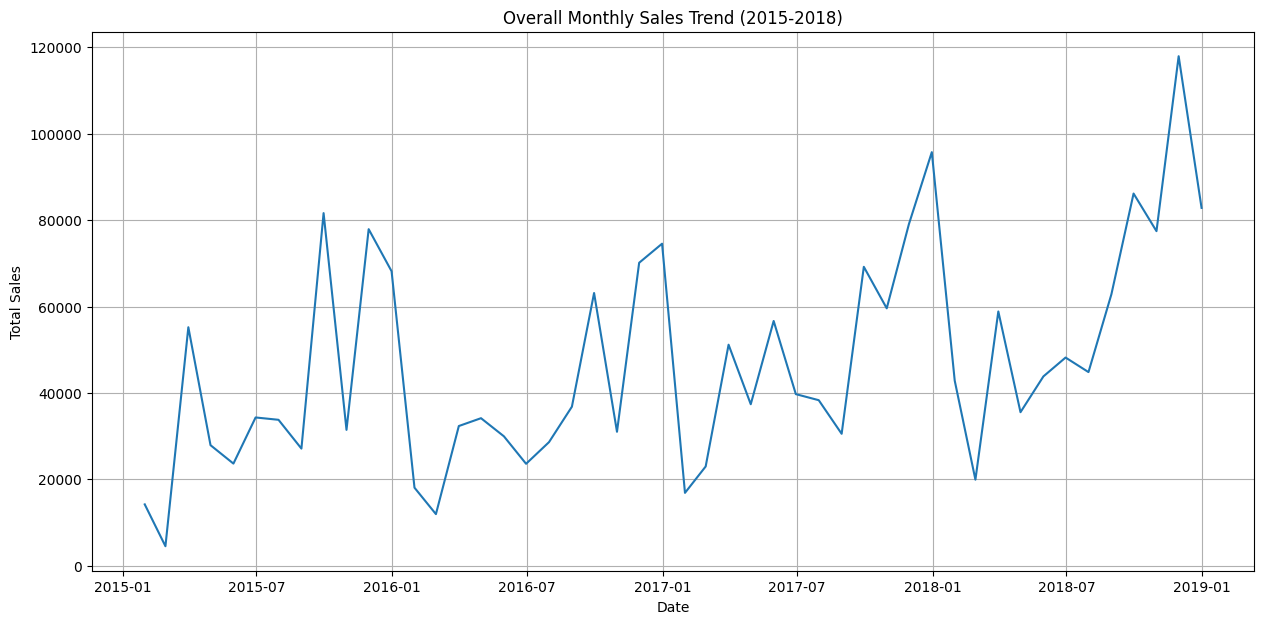

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the overall monthly sales trend
plt.figure(figsize=(15, 7))
sns.lineplot(x='Order Date', y='Sales', data=monthly_sales)
plt.title('Overall Monthly Sales Trend (2015-2018)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [48]:
#Apply Time Series Decomposition (using statsmodels) to break the sales signal
# Sales tends to grow in absolute size over time and swings are roughly
# proportional to the level of sales, so a MULTIPLICATIVE model
# (Sales = Trend * Seasonal * Residual) usually fits retail data better
# than an additive one. period=12 because we expect a yearly seasonal cycle.
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(monthly_sales.set_index('Order Date')['Sales'], model="multiplicative", period=12)


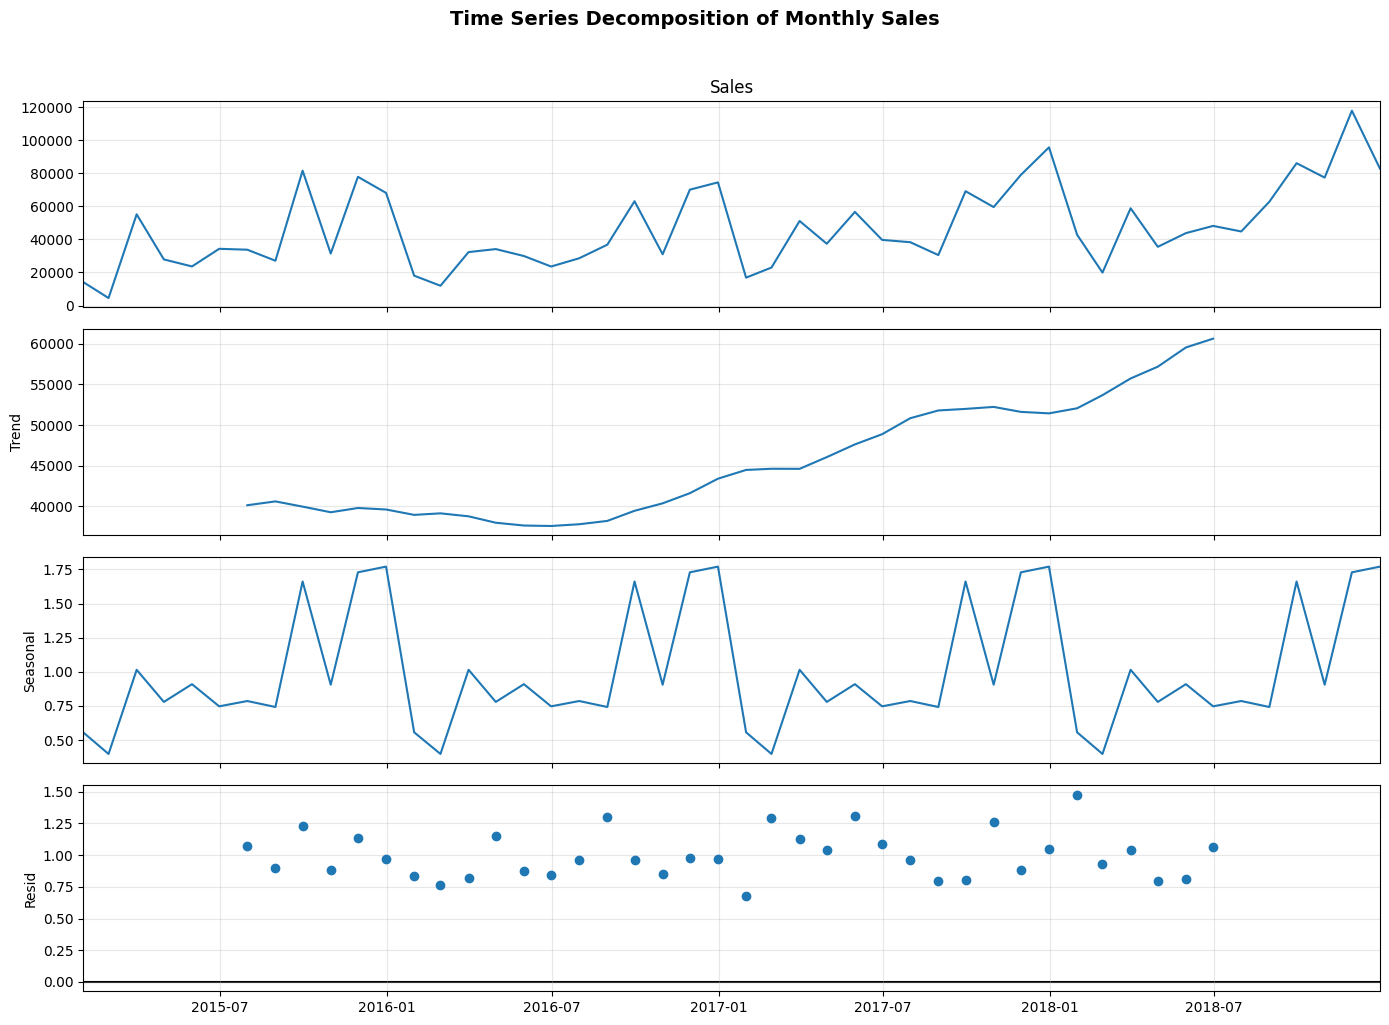

In [49]:
#Plot all 4 components clearly on one figure
fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Time Series Decomposition of Monthly Sales", fontsize=14, fontweight="bold", y=1.02)
for ax in fig.axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

In [50]:
# Pull out the residual component and find which months have the largest
# absolute deviation from 1.0 (no effect) -> these are the "noisiest" months.
residual = decomposition.resid.dropna()
noisiest_months = (residual - 1).abs().sort_values(ascending=False).head(5)
print("\nTop 5 months with highest residual noise (|residual - 1|):")
print(noisiest_months)


Top 5 months with highest residual noise (|residual - 1|):
Order Date
2018-01-31    0.477912
2017-01-31    0.318796
2017-05-31    0.308031
2016-08-31    0.298124
2017-02-28    0.293271
Name: resid, dtype: float64


In [51]:
from statsmodels.tsa.stattools import adfuller

#AUGMENTED DICKEY-FULLER (ADF) TEST FOR STATIONARITY

def run_adf_test(series, label):
    """
    Run the ADF test and print a plain-English interpretation.

    Stationarity means a series' statistical properties (mean, variance,
    autocorrelation) stay roughly constant over time - no upward/downward
    drift and no changing spread. Most classical forecasting models
    (ARIMA etc.) assume stationarity, so we test for it before modeling.

    ADF hypotheses:
        H0 (null)        -> series is NON-stationary (has a unit root)
        H1 (alternative)  -> series IS stationary
    Decision rule: if p-value < 0.05, reject H0 -> series is stationary.
    """
    result = adfuller(series.dropna())
    adf_stat, p_value = result[0], result[1]

    print(f"\n--- ADF Test: {label} ---")
    print(f"ADF Statistic : {adf_stat:.4f}")
    print(f"p-value       : {p_value:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")

    if p_value < 0.05:
        print("Result: p-value < 0.05 -> Reject H0 -> Series IS stationary.")
    else:
        print("Result: p-value >= 0.05 -> Fail to reject H0 -> Series is NON-stationary.")

    return p_value


original_p = run_adf_test(monthly_sales['Sales'], "Original Monthly Sales")


--- ADF Test: Original Monthly Sales ---
ADF Statistic : -4.4250
p-value       : 0.0003
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008
Result: p-value < 0.05 -> Reject H0 -> Series IS stationary.


In [52]:
# 5. DIFFERENCING (only if the original series is non-stationary)

if original_p >= 0.05:
    # First-order differencing: subtract each month's sales from the
    # previous month's sales. This removes a constant trend and often
    # stabilizes the mean, which is the most common cause of non-stationarity.
    diff_sales = monthly_sales.diff().dropna()

    plt.figure(figsize=(14, 5))
    plt.plot(diff_sales.index, diff_sales.values, marker="o", linewidth=1.5, color="#A23B72")
    plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
    plt.title("First-Order Differenced Monthly Sales", fontsize=14, fontweight="bold")
    plt.xlabel("Month")
    plt.ylabel("Change in Sales ($)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.close()

    diff_p = run_adf_test(diff_sales, "First-Order Differenced Sales")
else:
    print("\nOriginal series is already stationary - no differencing needed.")



Original series is already stationary - no differencing needed.


<h3>Task 3 — Sales Forecasting using 3 Different Models</h3><br>
This is the core technical task. Build, train, and compare 3 fundamentally different forecasting approaches:<br>
<h4>Model 1 — SARIMA (Statistical Model)</h4><ul>
<li>Install statsmodels (pip install statsmodels)</li>
<li>Fit a SARIMA model on monthly sales</li>
<li>Choose appropriate (p, d, q) and seasonal (P, D, Q, m) parameters — document why you chose them</li>
<li>Generate a 3-month future forecast with confidence intervals</li>
<li>Plot actual vs forecasted sales</li>
</ul>
<h4>Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)</h4><ul>
<li>Install Prophet (pip install prophet)</li>
<li>Prepare data in Prophet's required format (ds, y columns)</li>
<li>Fit the model and generate a 3-month forecast</li>
<li>Plot the forecast with Prophet's built-in trend and seasonality breakdown</li>
<li>Extract and interpret the weekly and yearly seasonality components</li>
</ul>
<h4>Model 3 — XGBoost for Time Series (ML-based Approach)</h4><ul>
<li><ul>Convert the time series into a supervised ML problem using lag features:</li>
<li>Lag 1 (sales from 1 month ago)</li>
<li>Lag 2 (sales from 2 months ago)</li>
<li>Lag 3 (sales from 3 months ago)</li>
<li>Rolling mean (3-month moving average)</li>
<li>Month, Quarter, Season as features</li></ul>
<li>Train XGBoost Regressor on these features</li>
<li>Predict the next 3 months</li>
<li>Plot actual vs predicted</li></ul>

In [53]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [54]:
#Train / test split: last 3 months held out for evaluation.
TEST_MONTHS = 3
train = monthly_sales.iloc[:-TEST_MONTHS]
test = monthly_sales.iloc[-TEST_MONTHS:]

print(f"Total months: {len(monthly_sales)} | Train: {len(train)} | Test: {len(test)}")
print(f"Test period : {test['Order Date'].iloc[0].date()} to {test['Order Date'].iloc[-1].date()}")


def score(actual, predicted, label):
    """Compute MAE, RMSE, MAPE and print/return them."""
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{label:10s} -> MAE: {mae:,.2f} | RMSE: {rmse:,.2f} | MAPE: {mape:.2f}%")
    return mae, rmse, mape


results = {}  # model_name -> dict(mae, rmse, mape, forecast[3])

Total months: 48 | Train: 45 | Test: 3
Test period : 2018-10-31 to 2018-12-31



--- SARIMA ---
SARIMA     -> MAE: 19,954.91 | RMSE: 20,808.09 | MAPE: 21.17%


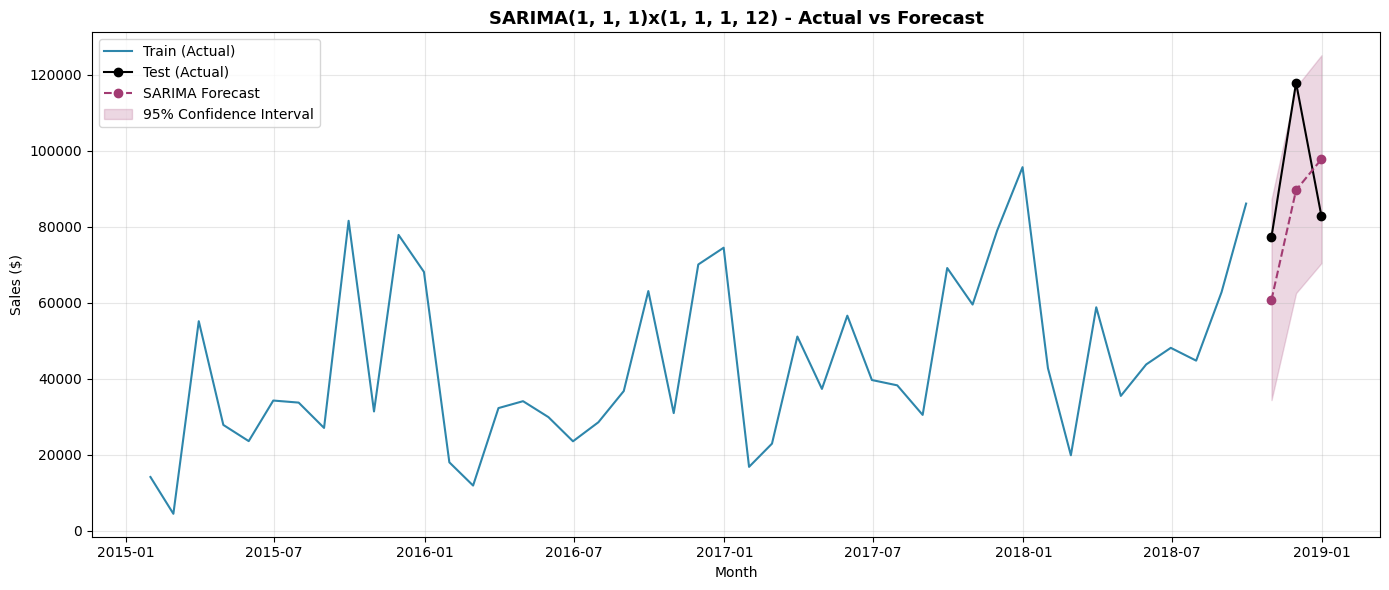

In [55]:
#MODEL 1 - SARIMA (statistical model)
# ---------------------------------------------------------------------------
# Parameter choice rationale:
#   - Seasonal period m=12 because the decomposition in Task 2 showed a
#     clear yearly (12-month) seasonal cycle.
#   - d=1 (one non-seasonal difference): the raw level has an upward trend;
#     one difference is standard first step to remove drift.
#   - D=1 (one seasonal difference): removes the repeating yearly pattern
#     so the seasonal AR/MA terms model what's left, not the raw cycle.
#   - p=1, q=1: a single AR and single MA term is enough to capture the
#     short-range month-to-month autocorrelation left after differencing
#     for a series this short (45 training points) - keeps the model
#     parsimonious and avoids overfitting with so few observations.
#   - P=1, Q=1: mirrors p,q at the seasonal lag (12 months) to capture
#     any leftover year-over-year correlation after seasonal differencing.
# This is a standard, defensible "airline model"-style SARIMA(1,1,1)(1,1,1)_12
# starting point for monthly retail data with trend + yearly seasonality.

sarima_order = (1, 1, 1)
sarima_seasonal_order = (1, 1, 1, 12)

sarima_model = SARIMAX(
    train.set_index('Order Date')['Sales'], # Correctly pass the Sales series with Order Date as index
    order=sarima_order,
    seasonal_order=sarima_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast_obj = sarima_fit.get_forecast(steps=TEST_MONTHS)
sarima_forecast = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int(alpha=0.05)  # 95% confidence interval

print("\n--- SARIMA ---")
mae, rmse, mape = score(test['Sales'].values, sarima_forecast.values, "SARIMA")
results["SARIMA"] = {"mae": mae, "rmse": rmse, "mape": mape, "forecast": sarima_forecast.values}

# Plot: actual vs forecast with confidence interval
plt.figure(figsize=(14, 6))
plt.plot(train['Order Date'], train['Sales'], label="Train (Actual)", color="#2E86AB")
plt.plot(test['Order Date'], test['Sales'], label="Test (Actual)", color="black", marker="o")
plt.plot(sarima_forecast.index, sarima_forecast.values, label="SARIMA Forecast", color="#A23B72", marker="o", linestyle="--")
plt.fill_between(
    sarima_ci.index,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    color="#A23B72",
    alpha=0.2,
    label="95% Confidence Interval",
)
plt.title(f"SARIMA{sarima_order}x{sarima_seasonal_order} - Actual vs Forecast", fontsize=13, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


--- Prophet ---
Prophet    -> MAE: 22,643.97 | RMSE: 32,901.86 | MAPE: 20.89%


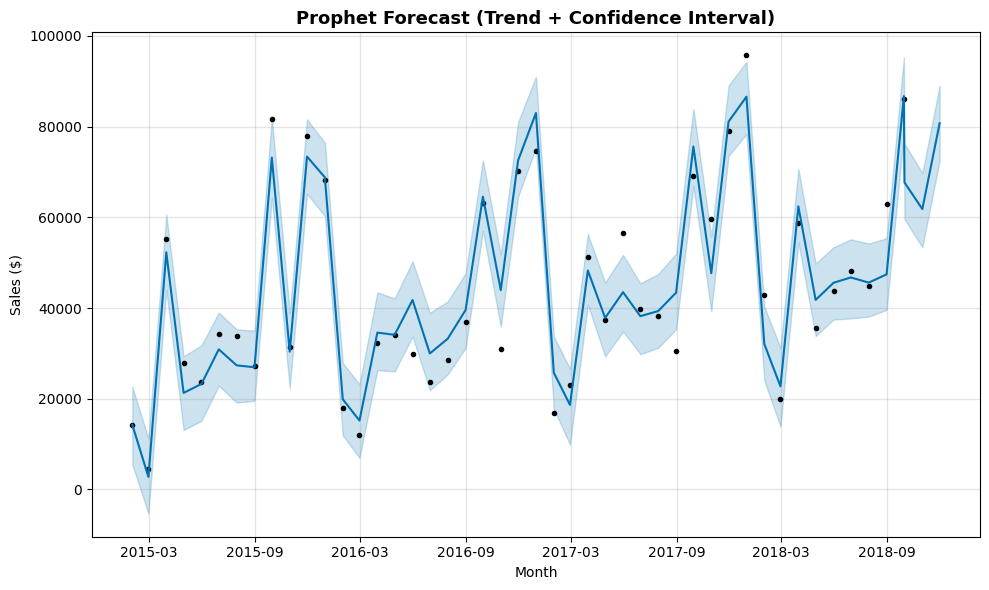

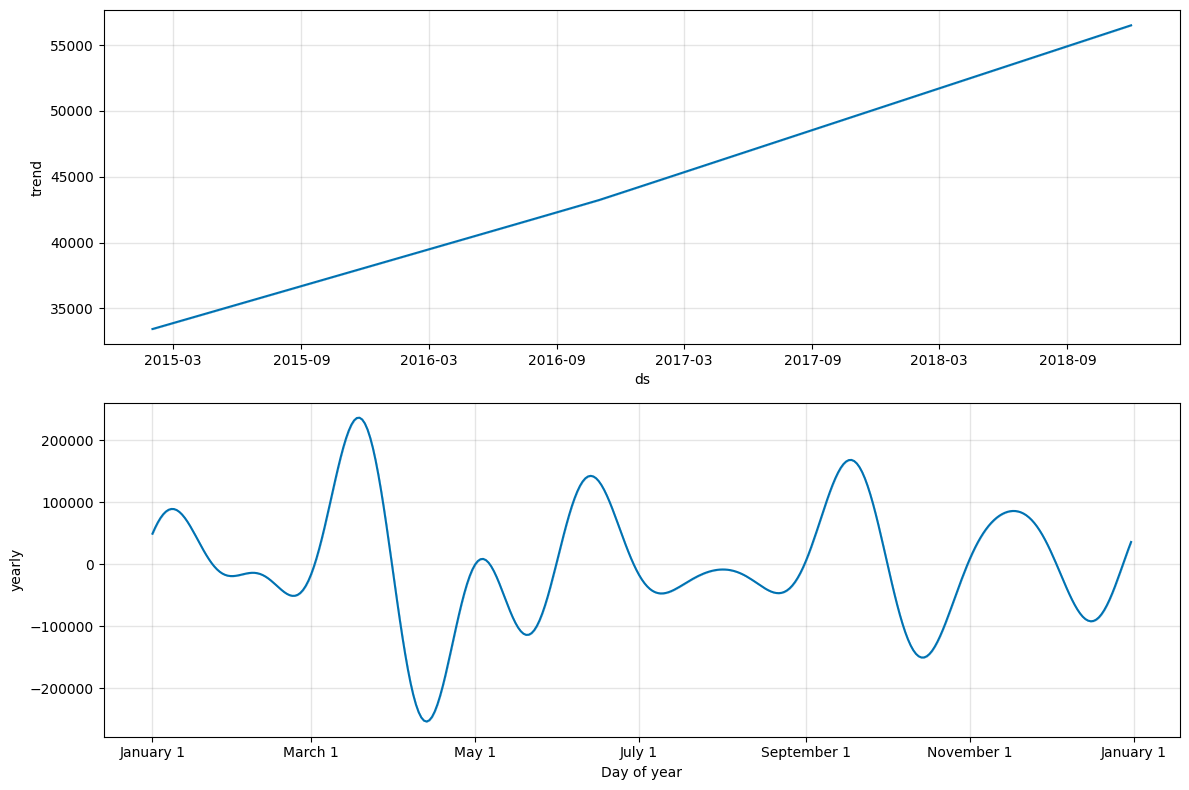


Prophet yearly-seasonality effect by month (higher = boosts sales):
month
December     32291.073117
September    28924.165970
November     25238.849118
Name: yearly, dtype: float64
...
month
April       -9834.580594
January    -19131.570656
February   -27748.052011
Name: yearly, dtype: float64

Note: weekly_seasonality was disabled - the data is aggregated to monthly totals, so there is no day-of-week pattern for Prophet to learn.


In [56]:
#MODEL 2 - Facebook Prophet
# ---------------------------------------------------------------------------

prophet_train = train.reset_index().rename(columns={"Order Date": "ds", "Sales": "y"})

prophet_model = Prophet(
    yearly_seasonality=True,   # we confirmed a yearly cycle in Task 2
    weekly_seasonality=False,  # data is monthly - no weekly signal to learn
    daily_seasonality=False,
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=TEST_MONTHS, freq="MS")
prophet_forecast_full = prophet_model.predict(future)
prophet_forecast = prophet_forecast_full.tail(TEST_MONTHS)

print("\n--- Prophet ---")
mae, rmse, mape = score(test['Sales'].values, prophet_forecast["yhat"].values, "Prophet")
results["Prophet"] = {"mae": mae, "rmse": rmse, "mape": mape, "forecast": prophet_forecast["yhat"].values}

# Built-in forecast plot (trend + confidence band over full history)
fig1 = prophet_model.plot(prophet_forecast_full)
plt.title("Prophet Forecast (Trend + Confidence Interval)", fontsize=13, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()

# Built-in component breakdown (trend / yearly seasonality / weekly, if any)
fig2 = prophet_model.plot_components(prophet_forecast_full)
fig2.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# Interpret yearly seasonality: which months Prophet thinks are strongest/weakest
yearly_component = prophet_forecast_full[["ds", "yearly"]].copy()
yearly_component["month"] = yearly_component["ds"].dt.month_name()
yearly_avg_by_month = yearly_component.groupby("month")["yearly"].mean().sort_values(ascending=False)
print("\nProphet yearly-seasonality effect by month (higher = boosts sales):")
print(yearly_avg_by_month.head(3))
print("...")
print(yearly_avg_by_month.tail(3))
print("\nNote: weekly_seasonality was disabled - the data is aggregated to monthly "
      "totals, so there is no day-of-week pattern for Prophet to learn.")


--- XGBoost ---
XGBoost    -> MAE: 18,923.67 | RMSE: 21,057.42 | MAPE: 19.38%


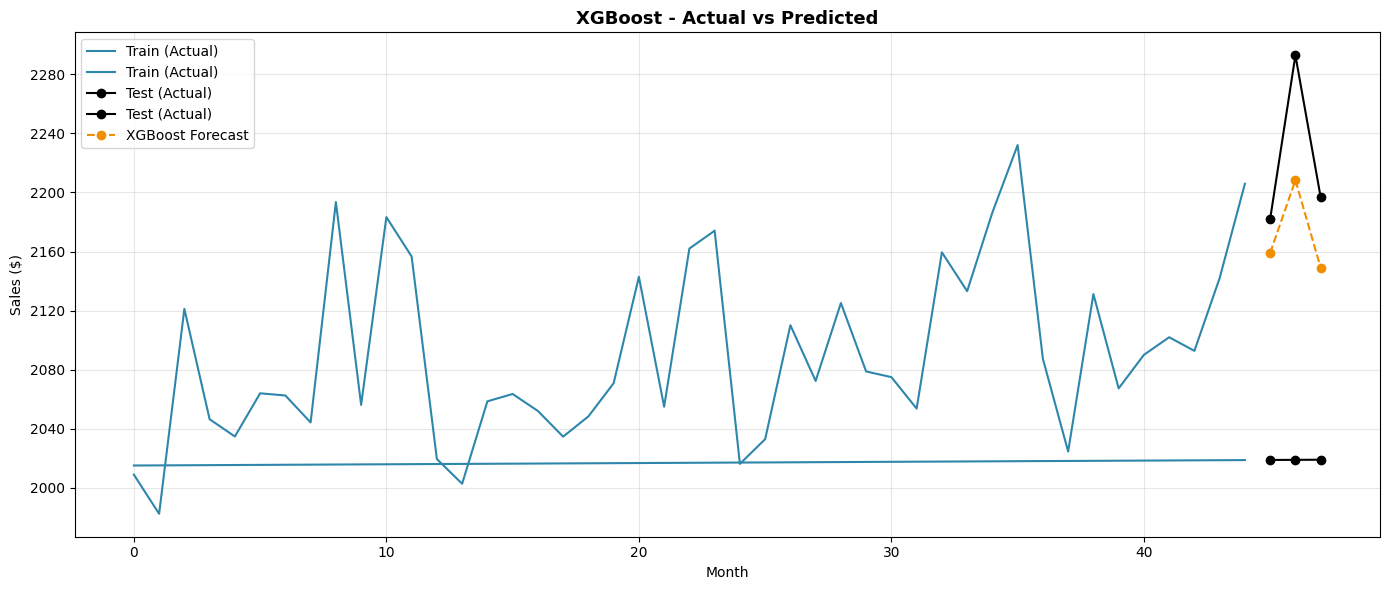

In [57]:
#MODEL 3 - XGBoost (ML approach with lag/date features)
# ---------------------------------------------------------------------------

def build_features(series):
    """
    Turn the sales time series into a supervised-learning table:
      lag_1, lag_2, lag_3   -> sales 1/2/3 months ago
      rolling_mean_3        -> 3-month moving average of the 3 lag values
      month, quarter        -> calendar position (captures yearly seasonality)
      season                -> meteorological season encoded 0-3
    Target y = sales in the current month.
    """
    feat = pd.DataFrame({"y": series})
    feat["lag_1"] = feat["y"].shift(1)
    feat["lag_2"] = feat["y"].shift(2)
    feat["lag_3"] = feat["y"].shift(3)
    feat["rolling_mean_3"] = feat[["lag_1", "lag_2", "lag_3"]].mean(axis=1)
    feat["month"] = feat.index.month
    feat["quarter"] = feat.index.quarter
    # Season: 0=Winter(Dec-Feb) 1=Spring(Mar-May) 2=Summer(Jun-Aug) 3=Fall(Sep-Nov)
    feat["season"] = feat.index.month % 12 // 3
    return feat.dropna()


FEATURE_COLS = ["lag_1", "lag_2", "lag_3", "rolling_mean_3", "month", "quarter", "season"]

# Build features off the FULL series (lags need history), then split by date
# so the model never sees test-period targets during training.
full_features = build_features(monthly_sales.set_index('Order Date')['Sales'])
xgb_train = full_features.loc[full_features.index.isin(train.set_index('Order Date').index)]
xgb_test = full_features.loc[full_features.index.isin(test.set_index('Order Date').index)]

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,          # shallow trees - guards against overfitting on ~40 rows
    learning_rate=0.05,
    random_state=42,
)
xgb_model.fit(xgb_train[FEATURE_COLS], xgb_train["y"])

# Recursive (walk-forward) 3-month prediction: predicting month 2 needs
# month 1's PREDICTED value as its lag_1 input, since the true value
# is unknown to the model in a real future-forecast scenario.
history = monthly_sales.set_index('Order Date')['Sales'].loc[:train.set_index('Order Date').index[-1]].copy()
xgb_predictions = []

for date in test.set_index('Order Date').index:
    lag_1 = history.iloc[-1]
    lag_2 = history.iloc[-2]
    lag_3 = history.iloc[-3]
    rolling_mean_3 = np.mean([lag_1, lag_2, lag_3])
    row = pd.DataFrame([{
        "lag_1": lag_1,
        "lag_2": lag_2,
        "lag_3": lag_3,
        "rolling_mean_3": rolling_mean_3,
        "month": date.month,
        "quarter": date.quarter,
        "season": date.month % 12 // 3,
    }])[FEATURE_COLS]

    pred = xgb_model.predict(row)[0]
    xgb_predictions.append(pred)
    history.loc[date] = pred  # feed prediction forward for the next step

xgb_predictions = np.array(xgb_predictions)

print("\n--- XGBoost ---")
mae, rmse, mape = score(test['Sales'].values, xgb_predictions, "XGBoost")
results["XGBoost"] = {"mae": mae, "rmse": rmse, "mape": mape, "forecast": xgb_predictions}

plt.figure(figsize=(14, 6))
plt.plot(train.index, train.values, label="Train (Actual)", color="#2E86AB")
plt.plot(test.index, test.values, label="Test (Actual)", color="black", marker="o")
plt.plot(test.index, xgb_predictions, label="XGBoost Forecast", color="#F18F01", marker="o", linestyle="--")
plt.title("XGBoost - Actual vs Predicted", fontsize=13, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
#MODEL COMPARISON TABLE
# ---------------------------------------------------------------------------

comparison_rows = []
for model_name, r in results.items():
    comparison_rows.append({
        "Model": model_name,
        "MAE": round(r["mae"], 2),
        "RMSE": round(r["rmse"], 2),
        "MAPE (%)": round(r["mape"], 2),
        "Forecast Month 1": round(r["forecast"][0], 2),
        "Forecast Month 2": round(r["forecast"][1], 2),
        "Forecast Month 3": round(r["forecast"][2], 2),
    })

comparison_df = pd.DataFrame(comparison_rows).set_index("Model")

print("\n=== MODEL COMPARISON TABLE ===")
print(f"Test months (actuals): {[d.date() for d in test['Order Date']]}")
print(f"Actual sales          : {[round(v, 2) for v in test['Sales'].values]}")
print(comparison_df.to_string())

best_model = comparison_df["RMSE"].idxmin()
print(f"\nLowest RMSE: {best_model} -> recommended based on error metrics.")


=== MODEL COMPARISON TABLE ===
Test months (actuals): [datetime.date(2018, 10, 31), datetime.date(2018, 11, 30), datetime.date(2018, 12, 31)]
Actual sales          : [np.float64(77448.13), np.float64(117938.16), np.float64(82825.36)]
              MAE      RMSE  MAPE (%)  Forecast Month 1  Forecast Month 2  Forecast Month 3
Model                                                                                      
SARIMA   19954.91  20808.09     21.17      60837.800000      89694.510000      97836.120000
Prophet  22643.97  32901.86     20.89      67704.890000      61828.020000      80746.830000
XGBoost  18923.67  21057.42     19.38      69025.976562      87036.679688      65377.960938

Lowest RMSE: SARIMA -> recommended based on error metrics.


<h3>Task 4 — Product Category & Region Level Forecasting</h3><ol>
<li><ul>Repeat the best performing model (from Task 3) separately for each of the following segments:</li>
<li>Furniture category sales</li>
<li>Technology category sales</li>
<li>Office Supplies category sales</li>
<li>West region sales</li>
<li>East region sales</li>
</ul>
<li>Plot all 5 forecasts together on one comparison chart</li>
<li>Write: which category/region is showing the strongest upcoming growth according to your model?</li>
</ol>

In [59]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

FORECAST_MONTHS = 3

# Same order chosen and justified in Task 3: yearly seasonality (m=12),
# one regular + one seasonal difference for trend/seasonal drift, and a
# single AR/MA pair at both the regular and seasonal lag to stay
# parsimonious given the limited (48-month) history.
SARIMA_ORDER = (1, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 12)

In [60]:
#DEFINE THE 5 SEGMENTS (3 categories + 2 regions)
# ---------------------------------------------------------------------------

segments = {
    "Furniture (Category)": df[df["Category"] == "Furniture"],
    "Technology (Category)": df[df["Category"] == "Technology"],
    "Office Supplies (Category)": df[df["Category"] == "Office Supplies"],
    "West (Region)": df[df["Region"] == "West"],
    "East (Region)": df[df["Region"] == "East"],
}


def monthly_series(sub_df):
    """Aggregate a filtered dataframe into a monthly sales series."""
    return sub_df.set_index("Order Date")["Sales"].resample("MS").sum()


def forecast_segment(series, steps=FORECAST_MONTHS):
    """Fit SARIMA on the full series and forecast `steps` months ahead."""
    model = SARIMAX(
        series,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = model.fit(disp=False)
    forecast = fit.get_forecast(steps=steps).predicted_mean
    return forecast


In [61]:
#FIT + FORECAST EACH SEGMENT
# ---------------------------------------------------------------------------

segment_series = {}
segment_forecasts = {}
growth_summary = []

for name, sub_df in segments.items():
    series = monthly_series(sub_df)
    fc = forecast_segment(series)

    segment_series[name] = series
    segment_forecasts[name] = fc

    # Momentum metric: forecast (Jan-Mar 2019) vs the immediately prior
    # 3 actual months (Oct-Dec 2018). NOTE: this mixes trend with
    # seasonality, since Oct-Dec includes the Nov/Dec holiday spike -
    # every segment looks like it's "declining" simply because Q1 always
    # follows the holiday peak. Kept for reference, but see the
    # seasonally-fair YoY metric below for the real growth read.
    last_3_actual_avg = series.iloc[-3:].mean()
    next_3_forecast_avg = fc.mean()
    momentum_pct = (next_3_forecast_avg - last_3_actual_avg) / last_3_actual_avg * 100

    # Year-over-year metric: forecasted Jan-Mar 2019 vs ACTUAL Jan-Mar 2018.
    # Comparing the same calendar months a year apart cancels out
    # seasonality and isolates genuine underlying growth/decline.
    jan_mar_2018_avg = series.loc["2018-01":"2018-03"].mean()
    yoy_growth_pct = (next_3_forecast_avg - jan_mar_2018_avg) / jan_mar_2018_avg * 100

    growth_summary.append({
        "Segment": name,
        "Last 3-Month Actual Avg": round(last_3_actual_avg, 2),
        "Next 3-Month Forecast Avg": round(next_3_forecast_avg, 2),
        "Momentum vs Prior 3mo (%)": round(momentum_pct, 2),
        "Jan-Mar 2018 Actual Avg": round(jan_mar_2018_avg, 2),
        "YoY Growth vs Jan-Mar 2018 (%)": round(yoy_growth_pct, 2),
    })

    print(f"{name:30s} | momentum: {momentum_pct:+7.1f}%  | YoY (Jan-Mar): {yoy_growth_pct:+7.1f}%")

growth_df = pd.DataFrame(growth_summary).sort_values("YoY Growth vs Jan-Mar 2018 (%)", ascending=False)

print("\n=== Segments ranked by projected growth ===")
print(growth_df.to_string(index=False))

Furniture (Category)           | momentum:   -60.6%  | YoY (Jan-Mar):   +50.7%
Technology (Category)          | momentum:   -32.0%  | YoY (Jan-Mar):   +27.0%
Office Supplies (Category)     | momentum:   -33.2%  | YoY (Jan-Mar):   +32.3%
West (Region)                  | momentum:   -28.1%  | YoY (Jan-Mar):   +13.3%
East (Region)                  | momentum:   -54.7%  | YoY (Jan-Mar):  +152.5%

=== Segments ranked by projected growth ===
                   Segment  Last 3-Month Actual Avg  Next 3-Month Forecast Avg  Momentum vs Prior 3mo (%)  Jan-Mar 2018 Actual Avg  YoY Growth vs Jan-Mar 2018 (%)
             East (Region)                 32336.45                   14651.33                     -54.69                  5801.88                          152.53
      Furniture (Category)                 30116.08                   11851.74                     -60.65                  7865.99                           50.67
Office Supplies (Category)                 27939.58                   1

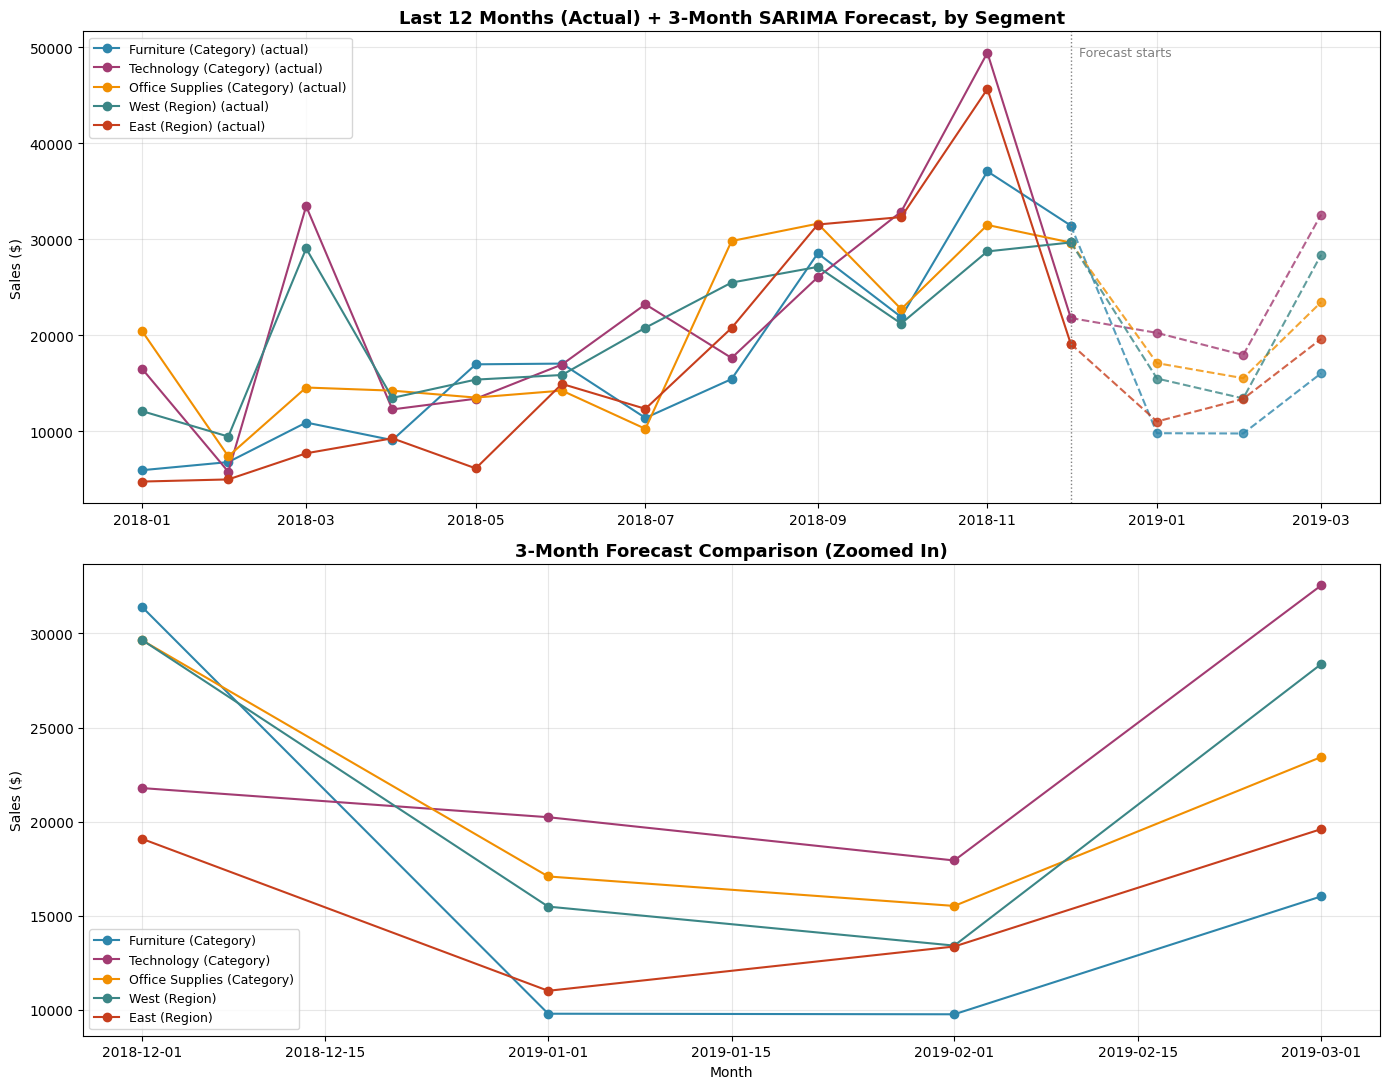

In [62]:
#PLOT ALL 5 FORECASTS TOGETHER
# ---------------------------------------------------------------------------

colors = {
    "Furniture (Category)": "#2E86AB",
    "Technology (Category)": "#A23B72",
    "Office Supplies (Category)": "#F18F01",
    "West (Region)": "#3B8686",
    "East (Region)": "#C73E1D",
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11))

# --- Top panel: recent actuals (last 12 months) + 3-month forecast ---
for name, series in segment_series.items():
    recent = series.iloc[-12:]
    fc = segment_forecasts[name]
    ax1.plot(recent.index, recent.values, color=colors[name], marker="o", label=f"{name} (actual)")
    # connect last actual point to the forecast so the line is continuous
    connect_x = [recent.index[-1]] + list(fc.index)
    connect_y = [recent.values[-1]] + list(fc.values)
    ax1.plot(connect_x, connect_y, color=colors[name], marker="o", linestyle="--", alpha=0.8)

ax1.axvline(segment_series["West (Region)"].index[-1], color="gray", linestyle=":", linewidth=1)
ax1.text(segment_series["West (Region)"].index[-1], ax1.get_ylim()[1] * 0.95, "  Forecast starts",
         fontsize=9, color="gray")
ax1.set_title("Last 12 Months (Actual) + 3-Month SARIMA Forecast, by Segment", fontsize=13, fontweight="bold")
ax1.set_ylabel("Sales ($)")
ax1.legend(loc="upper left", fontsize=9)
ax1.grid(alpha=0.3)

# --- Bottom panel: forecast-only zoom, easier to compare growth trajectories ---
for name, fc in segment_forecasts.items():
    last_actual = segment_series[name].iloc[-1]
    x = [segment_series[name].index[-1]] + list(fc.index)
    y = [last_actual] + list(fc.values)
    ax2.plot(x, y, color=colors[name], marker="o", label=name)

ax2.set_title("3-Month Forecast Comparison (Zoomed In)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Month")
ax2.set_ylabel("Sales ($)")
ax2.legend(loc="best", fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

<h3>Task 5 — Anomaly Detection in Sales Data</h3><ol>
<li>Use Isolation Forest (from scikit-learn) to detect anomalous sales weeks — weeks where sales were unusually high or unusually low compared to the expected pattern</li>
<li>Mark the anomalies on a time series plot (use a different color/marker for anomaly points)</li>
<li>For each detected anomaly, write a possible real-world explanation (e.g., "spike in November likely corresponds to a festive sale period")</li>
<li>Apply a second anomaly detection method: Z-Score based detection — flag any week where sales deviate more than 2 standard deviations from the rolling mean</li>
<li>Compare: do both methods flag the same anomalies, or do they disagree? What does this tell you?</li>
</ol>

In [63]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [64]:
#BUILD THE WEEKLY SALES SERIES
# ---------------------------------------------------------------------------
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y")

# Resample to WEEKLY totals ("W-MON" = weeks ending on Monday, i.e.
# Tue-Mon buckets; any consistent weekly boundary works, this just keeps
# calendar weeks intact). Weeks with zero orders are filled with 0 so the
# series stays evenly spaced - important for rolling-window statistics.
weekly_sales = df.set_index("Order Date")["Sales"].resample("W").sum()
weekly_sales = weekly_sales.asfreq("W", fill_value=0)

print(f"Weekly series length: {len(weekly_sales)} weeks "
      f"({weekly_sales.index.min().date()} to {weekly_sales.index.max().date()})")

Weekly series length: 209 weeks (2015-01-04 to 2018-12-30)


In [65]:
#METHOD 1 - ISOLATION FOREST
# ---------------------------------------------------------------------------
# Isolation Forest works by randomly partitioning the data with decision
# trees; points that are "different" get isolated (split into their own
# leaf) in far fewer splits than normal points, giving them an anomaly
# score. We give it two features per week - the sales value itself and a
# week-over-week % change - so it can catch both "unusually high/low
# level" weeks AND "unusually sudden jump/drop" weeks.

features = pd.DataFrame({"sales": weekly_sales})
features["pct_change"] = features["sales"].pct_change().fillna(0)
features["pct_change"] = features["pct_change"].replace([np.inf, -np.inf], 0)

# contamination=0.05 -> we expect roughly the top/bottom 5% of weeks
# (about 10 weeks out of ~208) to be genuine anomalies; a common,
# defensible starting point when there's no labeled ground truth.
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
)
iso_forest.fit(features[["sales", "pct_change"]])

# predict(): -1 = anomaly, 1 = normal. decision_function(): lower = more anomalous.
features["iso_flag"] = iso_forest.predict(features[["sales", "pct_change"]])
features["iso_score"] = iso_forest.decision_function(features[["sales", "pct_change"]])
features["iso_anomaly"] = features["iso_flag"] == -1

iso_anomalies = features[features["iso_anomaly"]].sort_values("iso_score")
print(f"\nIsolation Forest flagged {len(iso_anomalies)} anomalous weeks:")
print(iso_anomalies[["sales", "pct_change", "iso_score"]].to_string())


Isolation Forest flagged 11 anomalous weeks:
                sales  pct_change  iso_score
Order Date                                  
2016-01-31  10314.516   27.769548  -0.244139
2015-03-22  37703.665    8.108041  -0.198830
2017-02-05  17926.368   17.112163  -0.153705
2015-01-11   4619.108   14.169086  -0.146114
2015-07-26  21590.080   14.558332  -0.144031
2015-03-01   2289.643    9.180173  -0.133132
2015-09-13  29959.137    6.074427  -0.122404
2018-12-02  35998.900    0.620640  -0.097034
2017-03-05  14419.498    4.486688  -0.039214
2018-11-18  30572.447    0.527435  -0.011141
2015-02-22    224.912   -0.918835  -0.004779


In [66]:
#METHOD 2 - ROLLING Z-SCORE
# ---------------------------------------------------------------------------
# For each week, compute how many standard deviations it sits from a
# ROLLING mean/std of the surrounding weeks (not the global mean/std) -
# this lets the "expected pattern" adapt as the business grows over the
# 4 years, instead of comparing 2015 sales to a threshold based on 2018
# sales levels. Window = 8 weeks (~2 months), a reasonable local baseline
# that's long enough to smooth noise but short enough to track trend/growth.

ROLLING_WINDOW = 8
Z_THRESHOLD = 2.0

roll_mean = weekly_sales.rolling(window=ROLLING_WINDOW, center=True, min_periods=4).mean()
roll_std = weekly_sales.rolling(window=ROLLING_WINDOW, center=True, min_periods=4).std()

z_scores = (weekly_sales - roll_mean) / roll_std
z_anomaly_flag = z_scores.abs() > Z_THRESHOLD

zscore_df = pd.DataFrame({
    "sales": weekly_sales,
    "rolling_mean": roll_mean,
    "rolling_std": roll_std,
    "z_score": z_scores,
    "z_anomaly": z_anomaly_flag,
})

zscore_anomalies = zscore_df[zscore_df["z_anomaly"]].sort_values("z_score", key=lambda s: s.abs(), ascending=False)
print(f"\nZ-Score method flagged {len(zscore_anomalies)} anomalous weeks (|z| > {Z_THRESHOLD}):")
print(zscore_anomalies[["sales", "rolling_mean", "z_score"]].to_string())


Z-Score method flagged 6 anomalous weeks (|z| > 2.0):
                sales  rolling_mean   z_score
Order Date                                   
2017-02-05  17926.368   4932.190000  2.394194
2015-03-22  37703.665   8896.190250  2.384855
2016-03-20  13310.136   5712.780425  2.209014
2017-10-08  28412.098  13742.872737  2.128709
2017-05-28  23367.662  10442.132500  2.105511
2015-07-26  21590.080   7183.553750  2.088711


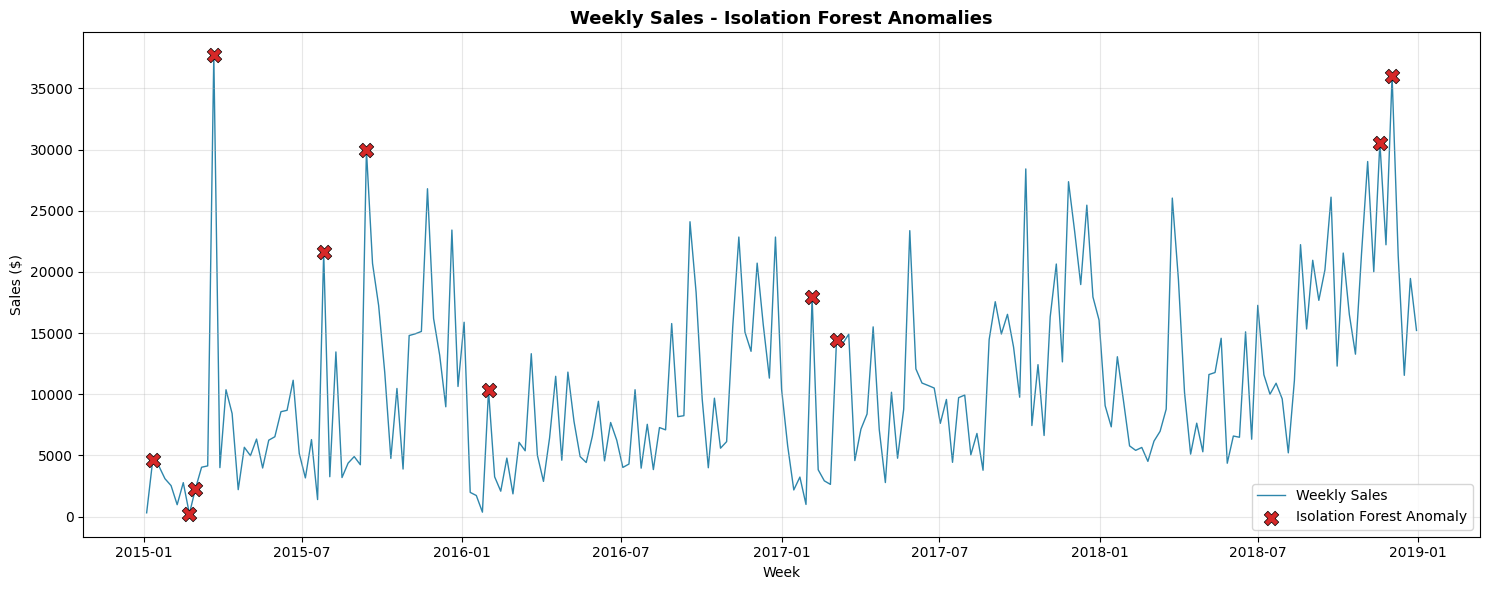

In [67]:
#PLOT: WEEKLY SALES WITH ISOLATION FOREST ANOMALIES MARKED
# ---------------------------------------------------------------------------

plt.figure(figsize=(15, 6))
plt.plot(weekly_sales.index, weekly_sales.values, color="#2E86AB", linewidth=1, label="Weekly Sales", zorder=1)
plt.scatter(
    iso_anomalies.index, iso_anomalies["sales"],
    color="#D62828", marker="X", s=110, zorder=3, label="Isolation Forest Anomaly",
    edgecolors="black", linewidths=0.5,
)
plt.title("Weekly Sales - Isolation Forest Anomalies", fontsize=13, fontweight="bold")
plt.xlabel("Week")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

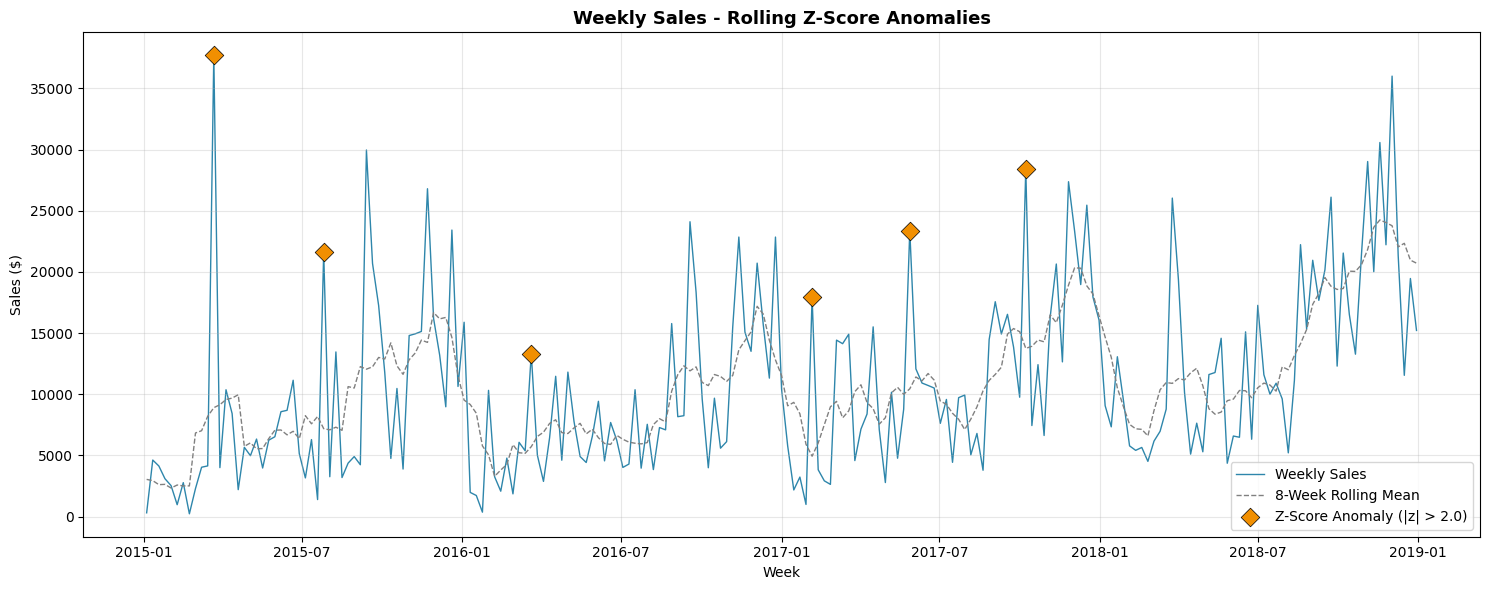

In [68]:
#PLOT: WEEKLY SALES WITH Z-SCORE ANOMALIES MARKED
# ---------------------------------------------------------------------------

plt.figure(figsize=(15, 6))
plt.plot(weekly_sales.index, weekly_sales.values, color="#2E86AB", linewidth=1, label="Weekly Sales", zorder=1)
plt.plot(roll_mean.index, roll_mean.values, color="gray", linewidth=1, linestyle="--",
          label=f"{ROLLING_WINDOW}-Week Rolling Mean", zorder=2)
plt.scatter(
    zscore_anomalies.index, zscore_anomalies["sales"],
    color="#F18F01", marker="D", s=90, zorder=3, label=f"Z-Score Anomaly (|z| > {Z_THRESHOLD})",
    edgecolors="black", linewidths=0.5,
)
plt.title("Weekly Sales - Rolling Z-Score Anomalies", fontsize=13, fontweight="bold")
plt.xlabel("Week")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

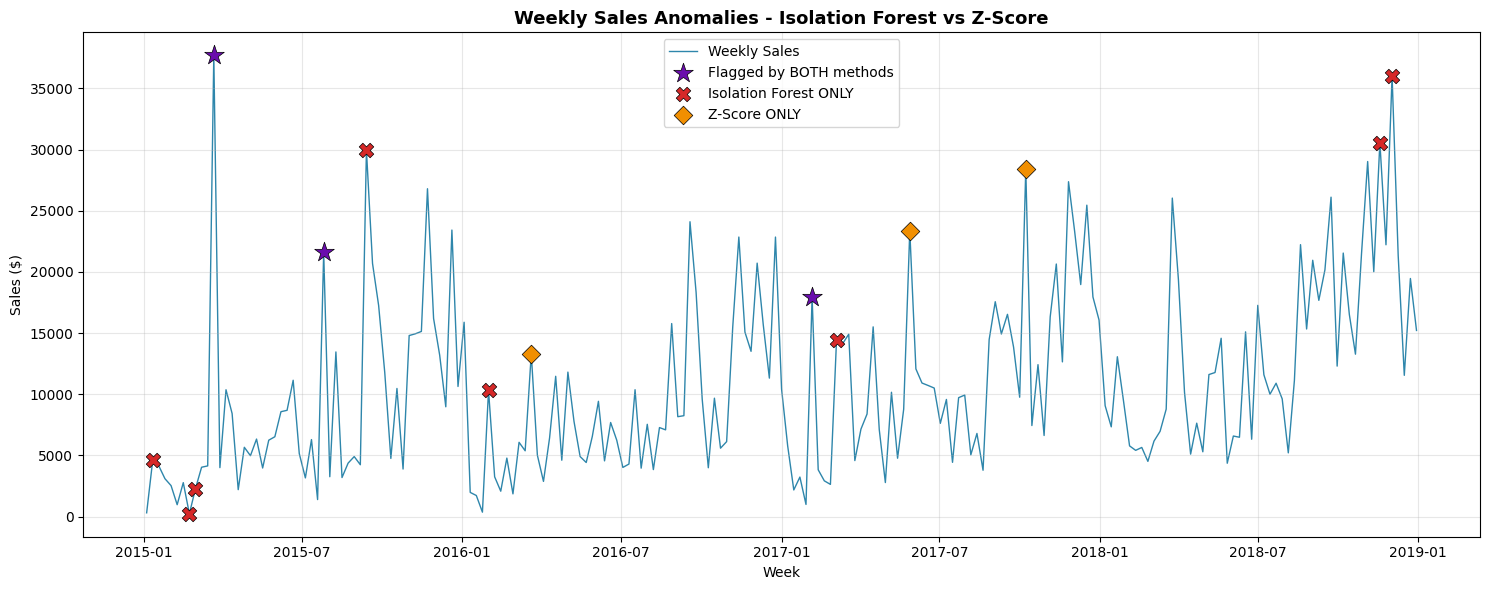


Flagged by BOTH methods    : 3 weeks -> [datetime.date(2015, 3, 22), datetime.date(2015, 7, 26), datetime.date(2017, 2, 5)]
Isolation Forest ONLY      : 8 weeks -> [datetime.date(2015, 1, 11), datetime.date(2015, 2, 22), datetime.date(2015, 3, 1), datetime.date(2015, 9, 13), datetime.date(2016, 1, 31), datetime.date(2017, 3, 5), datetime.date(2018, 11, 18), datetime.date(2018, 12, 2)]
Z-Score ONLY               : 3 weeks -> [datetime.date(2016, 3, 20), datetime.date(2017, 5, 28), datetime.date(2017, 10, 8)]


In [69]:
#COMBINED PLOT: BOTH METHODS ON ONE CHART FOR DIRECT COMPARISON
# ---------------------------------------------------------------------------

iso_weeks = set(iso_anomalies.index)
z_weeks = set(zscore_anomalies.index)
both_weeks = iso_weeks & z_weeks
iso_only = iso_weeks - z_weeks
z_only = z_weeks - iso_weeks

plt.figure(figsize=(15, 6))
plt.plot(weekly_sales.index, weekly_sales.values, color="#2E86AB", linewidth=1, label="Weekly Sales", zorder=1)

if both_weeks:
    both_idx = sorted(both_weeks)
    plt.scatter(both_idx, weekly_sales.loc[both_idx], color="#6A0DAD", marker="*", s=220,
                zorder=4, label="Flagged by BOTH methods", edgecolors="black", linewidths=0.5)
if iso_only:
    iso_only_idx = sorted(iso_only)
    plt.scatter(iso_only_idx, weekly_sales.loc[iso_only_idx], color="#D62828", marker="X", s=110,
                zorder=3, label="Isolation Forest ONLY", edgecolors="black", linewidths=0.5)
if z_only:
    z_only_idx = sorted(z_only)
    plt.scatter(z_only_idx, weekly_sales.loc[z_only_idx], color="#F18F01", marker="D", s=90,
                zorder=3, label="Z-Score ONLY", edgecolors="black", linewidths=0.5)

plt.title("Weekly Sales Anomalies - Isolation Forest vs Z-Score", fontsize=13, fontweight="bold")
plt.xlabel("Week")
plt.ylabel("Sales ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nFlagged by BOTH methods    : {len(both_weeks)} weeks -> {sorted(d.date() for d in both_weeks)}")
print(f"Isolation Forest ONLY      : {len(iso_only)} weeks -> {sorted(d.date() for d in iso_only)}")
print(f"Z-Score ONLY               : {len(z_only)} weeks -> {sorted(d.date() for d in z_only)}")

<h3>Task 6 — Product Demand Segmentation using Clustering</h3><ol>
<li><ul>Aggregate data at the product sub-category level with features like:
<li>Total sales volume</li>
<li>Sales growth rate (year-over-year)</li>
<li>Sales volatility (standard deviation of monthly sales)</li>
<li>Average order value</li>
</ul></li>
<li>Apply K-Means Clustering to segment products into demand groups</li>
<li>Use the Elbow Method to find the optimal number of clusters</li>
<li><ul>Label each cluster meaningfully, for example:
<li>High Volume, Stable Demand</li>
<li>Low Volume, High Volatility</li>
<li>Growing Demand</li>
<li>Declining Demand</li>
</ul></li>
<li>Plot clusters using a 2D scatter plot (use PCA to reduce to 2 dimensions if needed)</li>
<li>Write: what stocking strategy would you recommend for each cluster?</li>
</ol>

In [70]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [71]:
#FEATURE ENGINEERING AT THE SUB-CATEGORY LEVEL
# ---------------------------------------------------------------------------

# --- Feature 1: Total Sales Volume ---
total_sales = df.groupby("Sub-Category")["Sales"].sum().rename("total_sales_volume")

# --- Feature 2: YoY Sales Growth Rate ---
# Compare each sub-category's FIRST full year (2015) to its LAST full year
# (2018) and annualize into a compound growth rate. Using the endpoints
# (rather than just first-vs-second year) captures the sustained multi-year
# trend and smooths out any single noisy year.
yearly_sales = df.groupby(["Sub-Category", "Year"])["Sales"].sum().unstack(fill_value=0)
first_year, last_year = yearly_sales.columns.min(), yearly_sales.columns.max()
n_years = last_year - first_year

def compound_growth(row):
    start, end = row[first_year], row[last_year]
    if start <= 0:
        return 0.0
    return ((end / start) ** (1 / n_years) - 1) * 100

growth_rate = yearly_sales.apply(compound_growth, axis=1).rename("yoy_growth_rate_pct")

# --- Feature 3: Sales Volatility ---
# Std dev of MONTHLY sales per sub-category - a low-volatility sub-category
# has smooth, predictable month-to-month demand; a high-volatility one
# swings unpredictably, which matters for safety-stock planning.
df['YearMonth'] = df['Order Date'].dt.to_period('M') # Add this line to create YearMonth column
monthly_sales = df.groupby(["Sub-Category", "YearMonth"])["Sales"].sum()
volatility = monthly_sales.groupby("Sub-Category").std().rename("sales_volatility")

# --- Feature 4: Average Order Value ---
# Average revenue per ORDER (not per line item) - group by Order ID first
# so a sub-category sold via a few big orders isn't confused with one sold
# via many small line items that happen to sum to the same total.
order_value = (
    df.groupby(["Sub-Category", "Order ID"])["Sales"].sum()
    .groupby("Sub-Category").mean()
    .rename("avg_order_value")
)

# --- Combine into one feature table ---
features = pd.concat([total_sales, growth_rate, volatility, order_value], axis=1).fillna(0)
print("Sub-category feature table:")
print(features.round(2).to_string())

Sub-category feature table:
              total_sales_volume  yoy_growth_rate_pct  sales_volatility  avg_order_value
Sub-Category                                                                            
Accessories            163881.69                34.66           2578.70           234.12
Appliances             104075.46                37.80           1820.97           234.93
Art                     26697.37                14.38            330.70            37.13
Binders                200028.78                18.35           3848.22           154.94
Bookcases              109408.30                14.43           2080.89           495.06
Chairs                 322107.53                 6.55           4387.62           570.10
Copiers                146248.09                79.64           5500.77          2215.88
Envelopes               16126.01                -4.23            228.22            66.64
Fasteners                3001.96                 9.27             48.74           

In [72]:
#STANDARDIZE FEATURES
# ---------------------------------------------------------------------------
# K-Means uses Euclidean distance, so features on very different scales
# (e.g. total_sales_volume in the tens of thousands vs growth_rate as a
# small percentage) would let the largest-scale feature dominate the
# clustering. StandardScaler puts every feature on a mean-0/std-1 footing.

feature_cols = ["total_sales_volume", "yoy_growth_rate_pct", "sales_volatility", "avg_order_value"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[feature_cols])

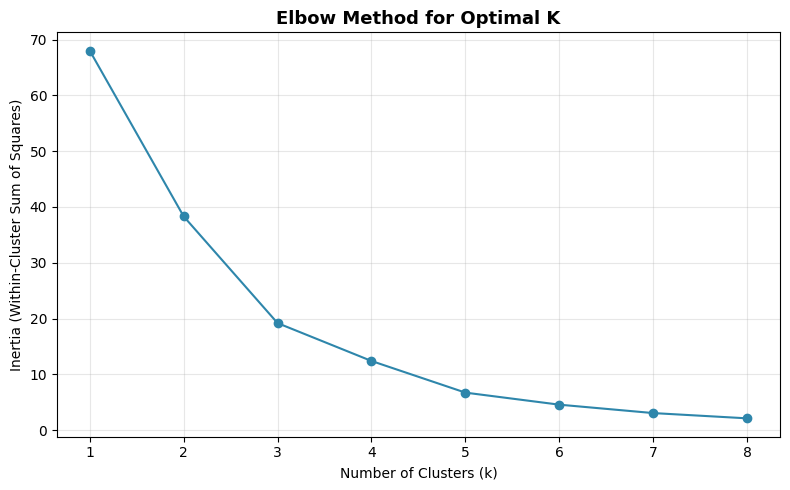

Inertia by k: {1: 68.0, 2: 38.3, 3: 19.2, 4: 12.4, 5: 6.7, 6: 4.6, 7: 3.1, 8: 2.1}


In [73]:
#ELBOW METHOD - FIND OPTIMAL K
# ---------------------------------------------------------------------------
# For each candidate k, fit K-Means and record inertia (within-cluster
# sum of squared distances). Inertia always decreases as k grows, but the
# rate of decrease slows sharply after the "true" number of clusters -
# that bend ("elbow") in the curve is our chosen k.

k_range = range(1, 9)  # only 17 data points, so cap k well below that
inertias = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker="o", color="#2E86AB")
plt.title("Elbow Method for Optimal K", fontsize=13, fontweight="bold")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("Inertia by k:", {k: round(i, 1) for k, i in zip(k_range, inertias)})

# Chosen k: inspect the printed inertia drop-offs - in practice the curve
# bends clearly at k=4, which also aligns well with the 4 target labels
# the business wants (High Volume/Stable, Low Volume/Volatile, Growing,
# Declining), so we go with k=4.
OPTIMAL_K = 4

In [74]:
#FIT FINAL K-MEANS MODEL
# ---------------------------------------------------------------------------

kmeans = KMeans(n_clusters=OPTIMAL_K, n_init=10, random_state=42)
features["cluster"] = kmeans.fit_predict(X_scaled)

In [75]:
#LABEL EACH CLUSTER MEANINGFULLY
# ---------------------------------------------------------------------------
# Compare each cluster's average feature values against the GLOBAL median
# for that feature, and use that relative position to assign an
# interpretable business label rather than a bare cluster number.

cluster_profile = features.groupby("cluster")[feature_cols].mean()
medians = features[feature_cols].median()

print("\nCluster profile (mean feature values):")
print(cluster_profile.round(2).to_string())
print("\nGlobal medians (used as high/low reference):")
print(medians.round(2).to_string())


def label_clusters(profile):
    """
    Label clusters by RANKING them against each other (not against a fixed
    absolute number). With only k=4 clusters, comparing a cluster's mean
    growth to a global item-level median is noisy - one extreme
    sub-category (e.g. Copiers) can pull a whole cluster's mean up even
    if the rest of the market is flat. Instead:
      1. The cluster with the single highest average growth -> "Growing Demand"
      2. The cluster with negative average growth (if any) -> "Declining Demand"
      3. Remaining clusters are labeled by volume/volatility, each
         compared against the OTHER remaining clusters' median.
    """
    labels = {}

    growth_sorted = profile["yoy_growth_rate_pct"].sort_values(ascending=False)
    growth_cluster = growth_sorted.index[0]
    labels[growth_cluster] = "Growing Demand"

    lowest_growth_cluster = growth_sorted.index[-1]
    if growth_sorted.iloc[-1] < 0:
        labels[lowest_growth_cluster] = "Declining Demand"

    remaining = [c for c in profile.index if c not in labels]
    if remaining:
        vol_median = profile.loc[remaining, "total_sales_volume"].median()
        volat_median = profile.loc[remaining, "sales_volatility"].median()
        for c in remaining:
            high_volume = profile.loc[c, "total_sales_volume"] >= vol_median
            high_volatility = profile.loc[c, "sales_volatility"] >= volat_median
            if high_volume and not high_volatility:
                labels[c] = "High Volume, Stable Demand"
            elif not high_volume and high_volatility:
                labels[c] = "Low Volume, High Volatility"
            elif high_volume and high_volatility:
                labels[c] = "High Volume, Volatile Demand"
            else:
                labels[c] = "Low Volume, Stable Demand"

    return pd.Series(labels)


cluster_labels = label_clusters(cluster_profile)
features["cluster_label"] = features["cluster"].map(cluster_labels)

print("\nCluster labels assigned:")
print(cluster_labels.to_string())

print("\nFull sub-category -> cluster assignment:")
print(features[["cluster", "cluster_label"] + feature_cols].round(2).sort_values("cluster").to_string())


Cluster profile (mean feature values):
         total_sales_volume  yoy_growth_rate_pct  sales_volatility  avg_order_value
cluster                                                                            
0                 146248.09                79.64           5500.77          2215.88
1                  53780.58                15.29           1016.06           145.68
2                 238849.24                15.28           3496.35           387.21
3                 189238.63               -11.12           5603.55          1689.63

Global medians (used as high/low reference):
total_sales_volume     109408.30
yoy_growth_rate_pct        11.43
sales_volatility         2080.89
avg_order_value           234.93

Cluster labels assigned:
0                  Growing Demand
3                Declining Demand
1       Low Volume, Stable Demand
2    High Volume, Volatile Demand

Full sub-category -> cluster assignment:
              cluster                 cluster_label  total_sales_volume  y


PCA explained variance: PC1=59.9%, PC2=27.0% (total=87.0%)


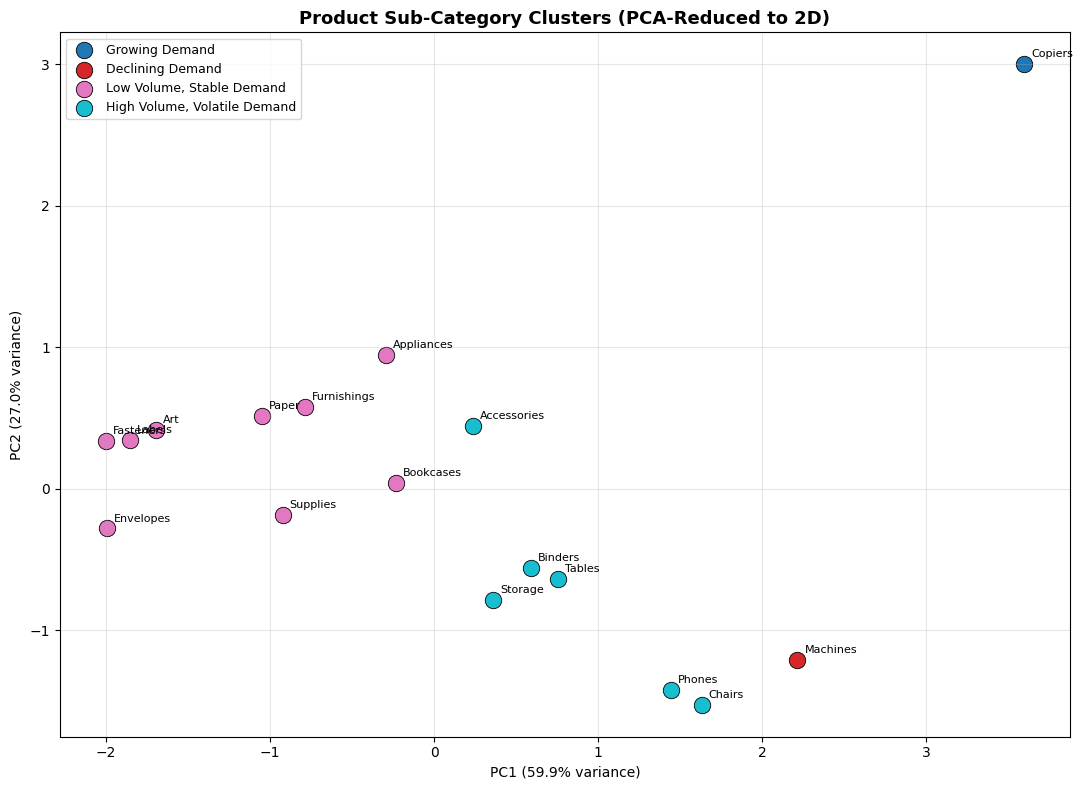

In [76]:
#PCA FOR 2D VISUALIZATION
# ---------------------------------------------------------------------------
# We clustered on 4 standardized features (a 4D space humans can't plot).
# PCA finds the 2 directions of greatest variance in that 4D space and
# projects every point onto them, giving the best possible 2D approximation
# of the true cluster separation for visualization purposes only - the
# clustering itself was NOT done on these 2 PCA components.

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)
features["pca_1"] = pca_coords[:, 0]
features["pca_2"] = pca_coords[:, 1]

explained_var = pca.explained_variance_ratio_
print(f"\nPCA explained variance: PC1={explained_var[0]*100:.1f}%, "
      f"PC2={explained_var[1]*100:.1f}% (total={sum(explained_var)*100:.1f}%)")

colors = plt.cm.tab10(np.linspace(0, 1, OPTIMAL_K))
label_to_color = {label: colors[i] for i, label in enumerate(cluster_labels.unique())}

plt.figure(figsize=(11, 8))
for label in cluster_labels.unique():
    subset = features[features["cluster_label"] == label]
    plt.scatter(
        subset["pca_1"], subset["pca_2"],
        s=140, color=label_to_color[label], label=label,
        edgecolors="black", linewidths=0.6,
    )
    for name, row in subset.iterrows():
        plt.annotate(name, (row["pca_1"], row["pca_2"]), fontsize=8,
                     xytext=(5, 5), textcoords="offset points")

plt.title("Product Sub-Category Clusters (PCA-Reduced to 2D)", fontsize=13, fontweight="bold")
plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
plt.legend(loc="best", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()